# Graph-Based Image Stitching

implements a robust pipeline to stitch fragmented satellite images into a unified large-scale map.

Unlike traditional sequential stitching approaches, this method:
- Uses **SIFT-based feature matching**
- Builds a **graph of image relationships**
- Applies **Maximum Spanning Tree (MST)** optimization
- Computes **global homographies**
- Performs **blending and rectification**

### Goal
To generate a geometrically consistent **top-down map** from unordered image fragments.


### Key Contributions
- Graph-based stitching
- MST to reduce alignment drift
- Global homography 
- Custom orthorectification module



In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import os
import json

## Step 1: Load Image Fragments

We load all image fragments from the dataset folder.

- Images are resized for faster processing
- Filenames are stored for reference and visualization

In [540]:
def load_images(folder):
    images = []
    names = []

    for file in sorted(os.listdir(folder)):
        path = os.path.join(folder, file)
        img = cv2.imread(path)

        if img is not None:
            img = cv2.resize(img, None, fx=0.6, fy=0.6)
            images.append(img)
            names.append(file)

    print(f"Loaded {len(images)} images")
    return images, names

images, names = load_images("DeepGlobe_Dataset/fragments_2/")

Loaded 9 images


### Preprocessing

Each image is converted to grayscale and histogram equalization is applied.

#### Why?
- Enhances contrast
- Improves feature detection (SIFT performs better)

In [408]:
def preprocess(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray = cv2.equalizeHist(gray)
    return gray

### Step 2: Feature Extraction (SIFT)

We use SIFT (Scale-Invariant Feature Transform) to detect keypoints and descriptors.

### Why SIFT?
- Robust to scale and rotation
- Works well for satellite imagery
- Captures distinctive features for matching

In [325]:
def extract_features(img):
    sift = cv2.SIFT_create()
    kp, des = sift.detectAndCompute(img, None)
    return kp, des

def show_keypoints(img, kp, title):
    out = cv2.drawKeypoints(img, kp, None, color=(0,255,0))

    plt.figure(figsize=(5,5))
    plt.imshow(cv2.cvtColor(out, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis('off')
    plt.show()

In [541]:
features = []

for i, img in enumerate(images):
    #img = cv2.resize(img, None, fx=scale, fy=scale)
    gray = preprocess(img)
    kp, des = extract_features(gray)
    features.append((kp, des))

    #show_keypoints(img, kp, f"Keypoints: {names[i]}")

## Step 3: Feature Matching

We match descriptors between image pairs using BFMatcher and apply Lowe’s ratio test.

### Why ratio test?
- Removes ambiguous matches
- Improves matching quality

In [327]:
def match_features(des1, des2):
    bf = cv2.BFMatcher()
    matches = bf.knnMatch(des1, des2, k=2)

    good = []
    for m, n in matches:
        if m.distance < 0.75 * n.distance:
            good.append(m)

    return good

## Step 4: Image Connectivity Graph

- Nodes = images
- Edges = strong feature matches

Only image pairs with sufficient matches are connected.

In [ ]:
def build_graph_fast(features, images, threshold=40):
    G = nx.Graph()

    for i in range(len(images)):
        G.add_node(i)

    for i in range(len(images)):
        for j in range(i+1, len(images)):

            kp1, des1 = features[i]
            kp2, des2 = features[j]

            if des1 is None or des2 is None:
                continue

            #limit descriptors
            des1 = des1[:7000]
            des2 = des2[:7000]

            matches = match_features(des1, des2)

            #  early reject
            if len(matches) > threshold:
                G.add_edge(i, j, weight=len(matches))

    return G

In [542]:

G = build_graph_fast(features, images)

In [536]:
def show_graph(G, names):
    plt.figure(figsize=(8,6))

    #A Spring Layout is a type of network visualization algorithm that uses the principles of physics to position nodes in a way that reveals the structure of the network. 
    pos = nx.spring_layout(G)
    nx.draw(G, pos, with_labels=True)

    #labels = {i: names[i] for i in G.nodes()}
    #nx.draw_networkx_labels(G, pos, labels)

    plt.title("Image Matching Graph")
    plt.show()


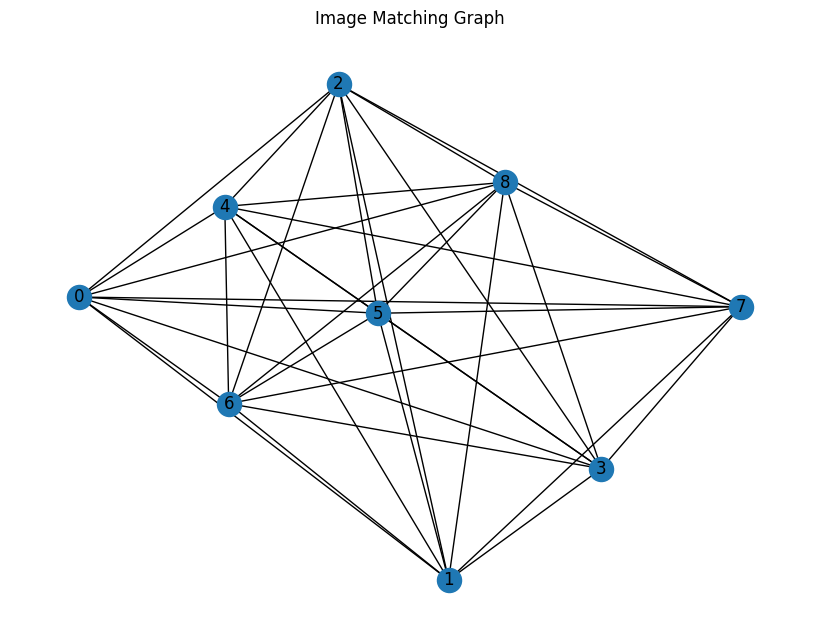

In [543]:

show_graph(G, names)

In [544]:
components = list(nx.connected_components(G))

print("Groups found:")
for comp in components:
    print(comp)

Groups found:
{0, 1, 2, 3, 4, 5, 6, 7, 8}


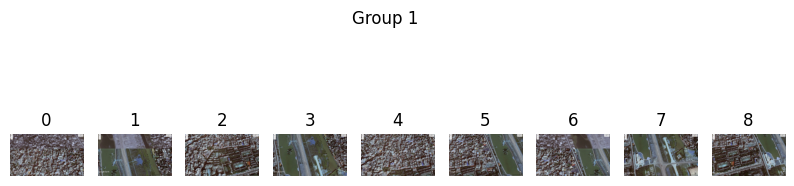

In [545]:
for i, comp in enumerate(components):
    plt.figure(figsize=(10,3))
    
    for j, node in enumerate(comp):
        plt.subplot(1, len(comp), j+1)
        plt.imshow(images[node])
        plt.title(f"{node}")
        plt.axis("off")
    
    plt.suptitle(f"Group {i+1}")
    plt.show()

Currently I use connected components for simplicity, but community detection could further improve robustness by grouping images based on strong feature similarity rather than mere connectivity

# Stiching and Blending

## Step 6: Maximum Spanning Tree (MST)

We extract the MST from the graph.

### Why MST?
- Keeps strongest connections
- Avoids cycles
- Reduces error accumulation (drift)


In [279]:
def build_mst(G, component):
    comp = list(component)
    mst = nx.maximum_spanning_tree(G.subgraph(comp))
    return list(mst.edges())

## Step 7: Pairwise Homography Estimation

Homography? : 
A transformation that maps points from one image plane to another.

We compute homography between image pairs using RANSAC.


##### RANSAC? 
- Removes outliers
- Ensures robust estimation

In [280]:
def compute_homography(i,j):
    kp1, des1 = features[i]
    kp2, des2 = features[j]

    matches = match_features(des1, des2)

    if len(matches) < 10:
        return None

    pts1 = np.float32([kp1[m.queryIdx].pt for m in matches])
    pts2 = np.float32([kp2[m.trainIdx].pt for m in matches])

    H, mask = cv2.findHomography(pts1, pts2, cv2.RANSAC, 5.0)

    return H

## Step 8: Global Homography Propagation

propagate transformations across the MST using DFS.

Instead of aligning images pairwise, we map all images into a **common global coordinate system**.

### Why separate from pairwise homography?
- Pairwise → local relation
- Global → unified map construction

In [281]:
def compute_global_H(component, mst):

    #root = list(component)[0]
    root = max(component, key=lambda x: len(features[x][1]) if features[x][1] is not None else 0)
    H_global = {root: np.eye(3)}

    adj = {i: [] for i in component}
    for u, v in mst:
        adj[u].append(v)
        adj[v].append(u)

    visited = set()

    def dfs(node):
        visited.add(node)

        for nei in adj[node]:
            if nei in visited:
                continue

            H = compute_homography(nei, node)
            #H = compute_homography(node, nei)
            #added line
            H = H / H[2,2]
            """
            if H is not None:
                H_global[nei] = H_global[node] @ H
                dfs(nei)

            """

            
        
    dfs(root)
    return H_global

Homography is directional, so the direction must align with the propagation logic. In my implementation, I compute H(neighbor → node) so that it composes correctly with the parent’s global transformation

We saved homographies so we can convert any point from a fragment image into the stitched map’s coordinate system, which is necessary to run pathfinding on a single unified map.

## Step 9: Warping Images to Global Space

- Compute global canvas size
- Apply perspective transformation
- Align all images into one coordinate frame

In [492]:
def warp_all(images, H_global):

    all_corners = []
    
    # Collect ALL warped corners
    for i in H_global:
        H = H_global[i]
        h, w = images[i].shape[:2]

        corners = np.float32([[0,0],[0,h],[w,h],[w,0]]).reshape(-1,1,2)
        warped_corners = cv2.perspectiveTransform(corners, H)

        all_corners.append(warped_corners)

    all_corners = np.concatenate(all_corners, axis=0)

    xmin, ymin = np.int32(all_corners.min(axis=0).ravel())
    xmax, ymax = np.int32(all_corners.max(axis=0).ravel())

    # GLOBAL translation
    T = np.array([[1,0,-xmin],
                  [0,1,-ymin],
                  [0,0,1]])
    
    width  = int(xmax - xmin)
    height = int(ymax - ymin)

    canvas_size = (width, height)

    #canvas_size = (xmax - xmin, ymax - ymin)

    """
    # SAVE HOMOGRAPHIES FOR PATHFINDING
    H_save = {}
    
    for idx, H in H_global.items():   # use same H you use for warping
        H_full = T @ H
        H_full = H_full / H_full[2,2]   # normalize

        H_save[idx] = H_full.tolist()

    with open("homographies_a1.json", "w") as f:
        json.dump(H_save, f, indent=2)

    print("Homographies saved")
    """
   

    warped = []
    masks = []
    corners = []

    # Warp ALL into SAME space
    for i in H_global:
        H = H_global[i]
        Ht = T @ H

        img = images[i]

        w_img = cv2.warpPerspective(img, Ht, canvas_size)

        mask = (w_img.sum(axis=2) > 0).astype(np.uint8) * 255

        warped.append(w_img.astype(np.float32))
        masks.append(mask)
        corners.append((0,0))  # ALL SAME FRAME

    return warped, masks, corners

In [155]:
"""
Bundle adjustment improves global alignment by jointly optimizing all camera transformations, 
but it is computationally expensive. Given time and resource constraints (CPU + deadline), 
I used MST-based global homography propagation as an efficient approximation
"""

'\nBundle adjustment improves global alignment by jointly optimizing all camera transformations, \nbut it is computationally expensive. Given time and resource constraints (CPU + deadline), \nI used MST-based global homography propagation as an efficient approximation\n'

## Step 10: Image Blending

We use Feather Blending to smoothly merge overlapping regions.

- Avoid sharp seams
- Improve visual consistency

In [379]:
def blend_final(warped, masks, corners):

    blender = cv2.detail_FeatherBlender()
    blender.setSharpness(0.02)

    h, w = warped[0].shape[:2]
    blender.prepare((0, 0, w, h))

    for i in range(len(warped)):
        blender.feed(warped[i].astype(np.int16), masks[i], corners[i])

    result, _ = blender.blend(None, None)
    return cv2.convertScaleAbs(result)

## Step 11: Cropping Black Regions

After stitching, black borders appear.

We remove them using bounding box detection.

In [284]:
def crop_black(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 1, 255, cv2.THRESH_BINARY)

    coords = cv2.findNonZero(thresh)
    x, y, w, h = cv2.boundingRect(coords)

    return img[y:y+h, x:x+w]

### RUN THE PIPELINE

Processing group: {0, 1, 2, 3, 4, 5, 6, 7, 8}


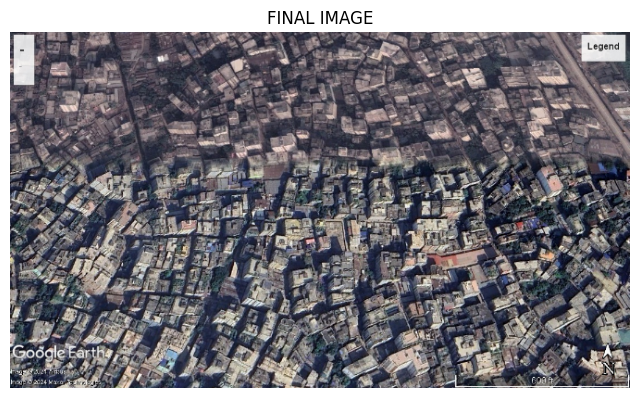

In [547]:
results = []

for comp in components:

    print(f"Processing group: {comp}")

    mst = build_mst(G, comp)

    H_global = compute_global_H(comp, mst)

    warped, masks, corners = warp_all(images, H_global)

    result = blend_final(warped, masks, corners)

    result = crop_black(result)

    plt.figure(figsize=(8,6))
    plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
    plt.title("FINAL IMAGE")
    plt.axis('off')
    plt.show()

    results.append(result)

# TOP-DOWN 2D MAP

In [51]:
import math
# maths - distance calculatoion

## Step 12: Orthorectification (Top-Down Map Conversion)

We detect the outer boundary and apply perspective correction.

### Why?
- Remove tilt/distortion
- Convert stitched image into a top-down map

### Key Steps:
- Detect non-black region
- Extract contour
- Approximate to 4 corners
- Apply homography



In [52]:
def get_corners(image):
    
    # mask - detect nonblack pixels (>15)
    mask = (image > 15).any(axis=2).astype(np.uint8)

    # Fill holes / morphology closing  ( why 7,7 ? )
    kernel = np.ones((7,7), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)  # why iteration 2 ?

    # find contours 
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    # python fn - max(list, key = function) - pick element from list for which the function value is highest 
    largest = max(contours, key=cv2.contourArea)  # look for largest contour area

    convex_hull = cv2.convexHull(largest)  # warps shape in smooth outer boundary and removes dents
    
    perimeter = cv2.arcLength(convex_hull, True) # compute perimeter
    crn_pt = None
    
    # shape it - stop when reach 4 points (adaptive epsilon)
    # creates evenly spaced numbers ( 50 values from 0.01 to 0.1)
    for epsilon in np.linspace(0.01, 0.1, 50):      # retrying over epsilon ( to get exact epsilon for 4 points )
        points = cv2.approxPolyDP(convex_hull, epsilon * perimeter, True)
        if len(points) == 4:
            crn_pt = points
            break

    # fallback - fit minimum rect around shape 
    if crn_pt is None or len(crn_pt) != 4:
        rect = cv2.minAreaRect(convex_hull)
        crn_pt = cv2.boxPoints(rect)

    pts = crn_pt.reshape(4,2).astype(np.float32)   # convert to array 

    #  Order points  -> tl , tr, br, bl
    sum = pts.sum(axis=1) # for each point s[i] = x+y : tl - smallest , br - largest
    diff = np.diff(pts, axis=1) # for each point d[i] = y-x : tr - smallest , bl - largest

    corners = np.zeros((4,2), dtype="float32")
    corners[0] = pts[np.argmin(sum)]      
    corners[1] = pts[np.argmin(diff)] 
    corners[2] = pts[np.argmax(sum)]
    corners[3] = pts[np.argmax(diff)] 

    # disatnce btw points - edges
    w1 = np.linalg.norm(corners[1] - corners[0]) # top width
    w2 = np.linalg.norm(corners[2] - corners[3]) # bottom width
    h1 = np.linalg.norm(corners[3] - corners[0]) # left height
    h2 = np.linalg.norm(corners[2] - corners[1]) # right height

    # pick max w and h , cal aspect ratio

    aspect_ratio = max(h1, h2) / (max(w1, w2) + 1e-6)

    return corners, aspect_ratio

In [53]:
def homography(image, pts, ar):

    (tl, tr, br, bl) = pts
    # ar = aspect ration 
    
    # cannot just give fixed values for final rectangle 
    width = int(max(
        np.linalg.norm(tr - tl),
        np.linalg.norm(br - bl)
    ))
    '''
    height = int(max(
        np.linalg.norm(bl - tl),
        np.linalg.norm(br - tr)
    ))
    if points are slightly wrong -> height becomes unstable , makes edges a bit incosistent 
    aspect ratio acts as a regularizer 
    '''

    height = int(width * ar)

    final_rect = np.array([
        [0,0],
        [width-1,0],
        [width-1,height-1],
        [0,height-1]
    ], dtype="float32")

    H = cv2.getPerspectiveTransform(pts, final_rect)
    warped = cv2.warpPerspective(image, H, (width, height))

    return warped

In [54]:
def rectification(image, val=False):
    h, w = image.shape[:2]      # get height and width of image
    y, x = np.indices((h, w))   # create coordinate grid 

    center_x, center_y = w // 2, h // 2     # get image center

    dis = np.sqrt((x - center_x)**2 + (y - center_y)**2)  #dis of every pixel from center
    weights = dis / dis.max()
    # normalize distance : center =0 , edge = 1 , to give edge pixel more importance
    
    mask = (image < 10).all(axis=2)   #  RGB channels <10 -> black
    weighted_black_pixels = mask.astype(np.float32) * weights 
    # black pixels -> weighted by distance ( non black -> zero )

    weighted_black = np.sum(weighted_black_pixels)  # total weighted black pixels
    total_weight = np.sum(weights) # total possible weight

    pixel_ratio = (weighted_black / total_weight) * 100

    if val:
        return pixel_ratio > 30
    else:
        return pixel_ratio > 20

In [55]:
def orthorectification(image):

    print("Is rectification needed ? :", rectification(image))

    if not rectification(image):
        return image

    pts, aspect_ratio = get_corners(image)

    #visualize detected corners
    detected_corners = image.copy()
    for (x, y) in pts:
        cv2.circle(detected_corners, (int(x), int(y)), 15, (0,0,255), -1)

    plt.figure(figsize=(6,5))
    plt.imshow(cv2.cvtColor(detected_corners, cv2.COLOR_BGR2RGB))
    plt.title("Detected Corners")
    plt.axis("off")
    plt.show()

    warped = homography(image, pts, aspect_ratio)

    # optional second check
    if rectification(warped, val=True):
        print("Still distorted → returning original")
        return image

    return warped

Is rectification needed ? : True


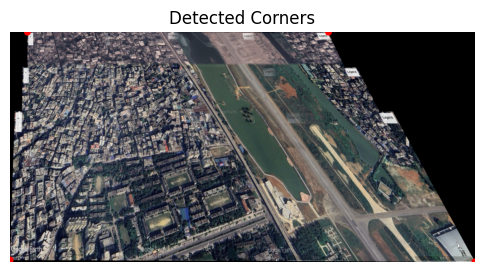

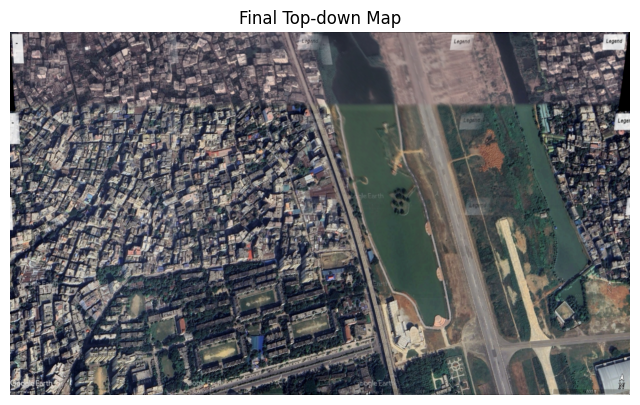

In [56]:
topdown = orthorectification(result)

plt.figure(figsize=(8,6))
plt.imshow(cv2.cvtColor(topdown, cv2.COLOR_BGR2RGB))
plt.title("Final Top-down Map")
plt.axis("off")
plt.show()

In [444]:
output_dir = "output/"
#Topdown_Map = cv2.cvtColor(topdown, cv2.COLOR_RGB2BGR)
cv2.imwrite(os.path.join(output_dir, "Topdown_Map_a1.png"), result[0])

True

## Conclusion

In this task, I developed a complete pipeline to generate a large-scale, top-down map from fragmented satellite images.

Instead of relying on traditional sequential stitching, I designed a **graph-based approach** where:
- Images are connected using feature similarity
- A **Maximum Spanning Tree (MST)** selects the most reliable relationships
- **Global homographies** are propagated to align all images in a common coordinate frame

This significantly reduces error accumulation and improves overall geometric consistency.

Additionally, a custom **orthorectification module** was implemented to correct perspective distortion and produce a cleaner top-down representation of the scene.

### Key Outcomes

- Successfully stitched multiple unordered fragments  
- Reduced drift using graph-based optimization  
- Achieved consistent global alignment  
- Generated a refined top-down map  

### Insights

- Local feature matching alone is insufficient for large-scale stitching  
- Global structure (via graphs) is critical for stability  
- Homography consistency is more important than individual accuracy  
- Simple geometric corrections can significantly improve final output  



##  Future Improvements

While the current pipeline produces reliable stitching results, several enhancements can further improve accuracy, robustness, and scalability:

###  1. Global Optimization (Bundle Adjustment)
- Current approach uses MST-based propagation
- Can be improved by optimizing all transformations jointly

###  2. Advanced Feature Matching
- Replace SIFT + BFMatcher with:
  - SuperPoint (feature extraction)
  - SuperGlue (matching)
- Improves performance in low-texture or repetitive regions

###  3. Seam Optimization
- Can be improved using:
  - Graph-cut seam finding
  - Multi-band blending
- Reduces visible seams and ghosting


### 4. Performance Optimization
- Parallel feature extraction and matching
- GPU acceleration (OpenCV CUDA / PyTorch integration)

